# Regularization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import scipy.io

from utils import*

----

### 1. Problem Statement
You have just been hired as an AI expert by the French Football Corporation. They would like you to recommend positions where France's goal keeper should kick the ball so that the French team's players can then hit it with their head. 

<img src="images/field_kiank.png" style="width:600px;height:350px;">

<caption><center><font color='purple'><b>Figure 1</b>: Football field. The goal keeper kicks the ball in the air, the players of each team are fighting to hit the ball with their head </font></center></caption>


They give you the following 2D dataset from France's past 10 games.

---

### 2.Load Dataset

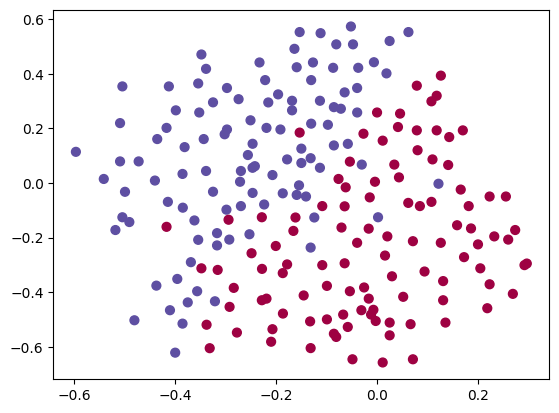

In [2]:
data = scipy.io.loadmat('datasets/data.mat')
train_X = data['X'].T
train_Y = data['y'].T
test_X = data['Xval'].T
test_Y = data['yval'].T

plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);   

Each dot corresponds to a position on the football field where a football player has hit the ball with his/her head after the French goal keeper has shot the ball from the left side of the football field.
- If the dot is blue, it means the French player managed to hit the ball with his/her head
- If the dot is red, it means the other team's player hit the ball with their head

**Your goal**: Use a deep learning model to find the positions on the field where the goalkeeper should kick the ball.

---

### 3. Non Regularized Model

In [3]:
def model(X, Y, layers_dims, learning_rate=0.3, num_iterations=30000, print_cost=True, lambd=0, keep_probs=None):
    """
    Implements an L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector, of shape (output size, number of examples)
    layers_dims -- list containing the input size and each layer size
    learning_rate -- learning rate of the optimization
    num_iterations -- number of iterations of the optimization loop
    print_cost -- If True, print the cost every 10000 iterations
    lambd -- L2 regularization hyperparameter, scalar
    keep_probs -- list of keep_prob values, one per hidden layer (e.g. [0.8, 0.7]).
                  Pass None or all 1.0s to disable dropout.
    
    Returns:
    parameters -- parameters learned by the model
    """
    
    costs = []                     # to keep track of the cost
    L = len(layers_dims) - 1       # number of layers

    
    # Initialize parameters dictionary
    parameters = initialize_parameters(layers_dims)

    # Loop (gradient descent)
    for i in range(0, num_iterations):
        # Forward propagation: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID
        AL, caches = L_model_forward(X, parameters, keep_probs)

        # Cost function
        if lambd == 0:
            cost = compute_cost(AL, Y)
        else:
            cost = compute_cost_regularized(AL, Y, parameters, lambd)

        # Backward propagation (dropout mask/keep_prob is cached per layer,
        # so no separate dropout branch is needed here — lambd handles L2,
        # dropout is applied automatically inside L_model_backward via the cache)
        grads = L_model_backward(AL, Y, caches, lambd)

        # Update parameters
        parameters = update_parameters(parameters, grads, learning_rate)

        # Print the loss every 10000 iterations
        if print_cost and i % 10000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
        if print_cost and i % 1000 == 0:
            costs.append(cost)

    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

Cost after iteration 0: 0.6557412523481002
Cost after iteration 10000: 0.1632998752572417
Cost after iteration 20000: 0.13851642423262905


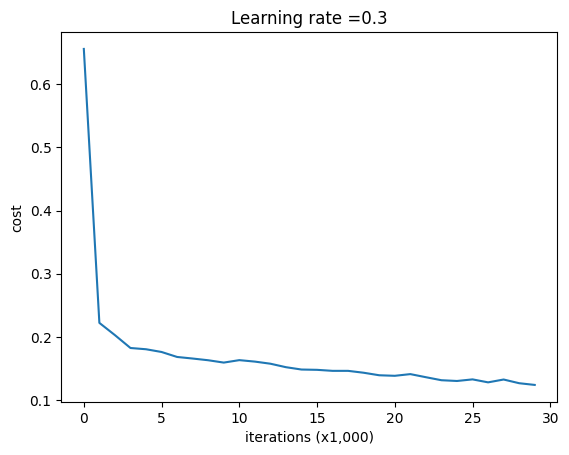

On the training set:
Accuracy: 0.9478672985781991
On the test set:
Accuracy: 0.9149999999999998


In [4]:
parameters = model(train_X, train_Y,layers_dims=[train_X.shape[0], 20, 3, 1])
print ("On the training set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

The train accuracy is 94.8% while the test accuracy is 91.5%. This is the **baseline model** (you will observe the impact of regularization on this model). Run the following code to plot the decision boundary of your model.

---

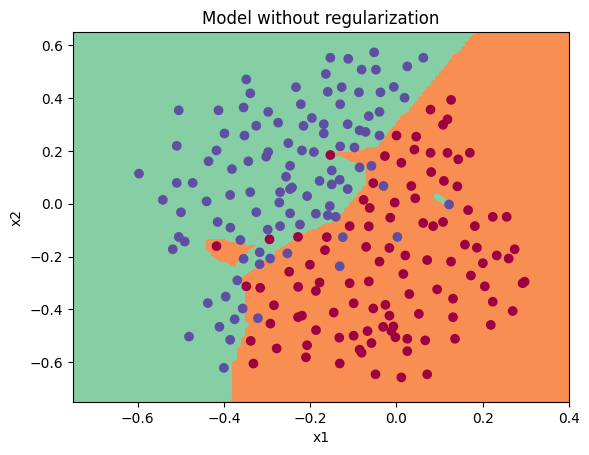

In [5]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

-----

### 4. L2 Regularization(Frobenian Norm)

The standard way to avoid overfitting is called **L2 regularization**. It consists of appropriately modifying your cost function, from:
$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$
To:
$$J_{regularized} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy cost} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularization cost} \tag{2}$$

In [6]:
def compute_cost_regularized (AL, Y,parameters,lambd):
    """
    Implement the cost function defined by equation (7).

    Arguments:
    AL -- probability vector corresponding to your label predictions, shape (1, number of examples)
    Y -- true "label" vector (for example: containing 0 if non-cat, 1 if cat), shape (1, number of examples)

    Returns:
    cost -- binary-cross-entropy cost
    """

    m = Y.shape[1]
    logprobs = np.multiply(-np.log(AL), Y) + np.multiply(-np.log(1 - AL), 1 - Y)
    cost = 1./m * np.nansum(logprobs)

    L = len(parameters)//2

    reg_cost = 0;

    for l in range(1,L+1):
        reg_cost += np.sum(np.square(parameters['W'+str(l)]))

    reg_cost = (lambd/(2*m))*reg_cost

    cost += reg_cost

    return cost

Implement the changes needed in backward propagation to take into account regularization. The changes only concern dW1, dW2 and dW3. For each, you have to add the regularization term's gradient ($\frac{d}{dW} ( \frac{1}{2}\frac{\lambda}{m}  W^2) = \frac{\lambda}{m} W$).

In [7]:
def linear_backward(dZ, cache,lambd):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """


    A_prev,W,b =cache
    m=A_prev.shape[1]


    dW = (1/m)*np.dot(dZ,A_prev.T)
    if(lambd>0):
        dW += (lambd/m)*W
        
    db = (1/m)*np.sum(dZ,axis=1,keepdims=True)

    dA_prev =np.dot(W.T,dZ)


    return dA_prev, dW, db

Cost after iteration 0: 0.6974484493131264
Cost after iteration 10000: 0.2684918873282239
Cost after iteration 20000: 0.2680916337127301


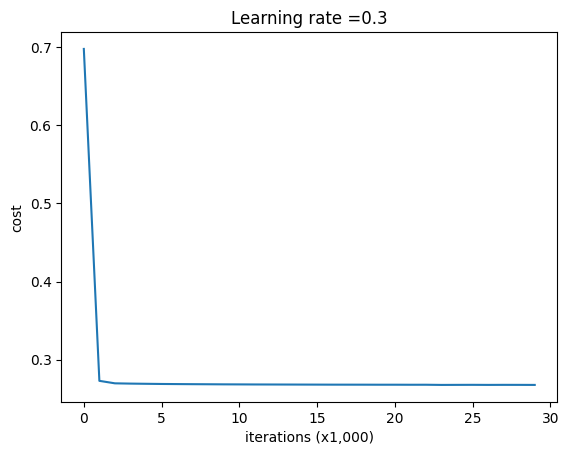

On the train set:
Accuracy: 0.9383886255924171
On the test set:
Accuracy: 0.9299999999999998


In [8]:
parameters = model(train_X, train_Y, layers_dims=[train_X.shape[0], 20, 3, 1], lambd = 0.7)
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

the test set accuracy increased to 93%.

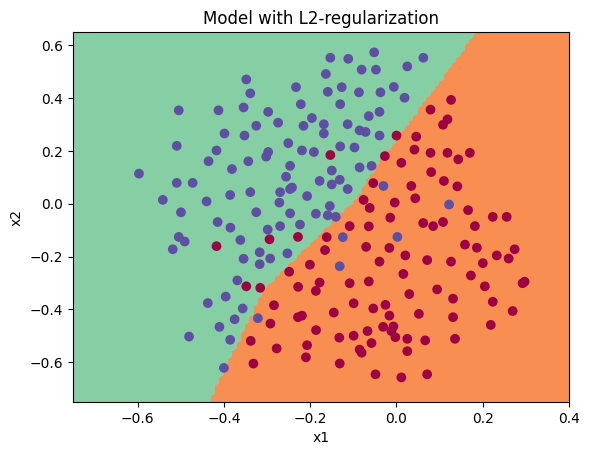

In [9]:
plt.title("Model with L2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

--------

### 5. DropOut Reg

**dropout** is a widely used regularization technique that is specific to deep learning. 
**It randomly shuts down some neurons in each iteration.**


**Forward propagation:**
- Randomly make neurons inactive with probability `(1 - keep_prob)`, keeping each neuron active with probability `keep_prob`.
- Steps:
  1. Generate mask: `D = (rand < keep_prob)`
  2. `A = A * D` → shut down selected neurons
  3. `A_used = A / keep_prob` → rescale so expected value remains same as without dropout (inverted dropout)

**Backward propagation:**
- `A_used` is a function of `A`, so `dJ/dA` is calculated using chain rule through this function.
- Since `A_used = A / keep_prob`:

$$\frac{dJ}{dA} = \frac{dJ}{dA_{used}} \times \frac{dA_{used}}{dA} = \frac{dJ}{dA_{used}} \times \frac{1}{keep\_prob}$$

- Steps:
  1. `dA = dA * D` → apply same mask used in forward prop for this layer
  2. `dA = dA / keep_prob` → derivative of `A_used = A/keep_prob` w.r.t. `A` is `1/keep_prob`

**Note:** No dropout on output layer. Set `keep_prob = 1.0` during gradient checking (random mask differs per call, breaks numerical comparison).

In [10]:
def L_model_forward(X , parameters,keep_probs):
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID computation
    
    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()
    keep_probs -- python list of keep_prob values, one per layer (e.g. [1.0, 0.7, 0.8, 1.0])
                  keep_probs[l] corresponds to the dropout applied AFTER layer l's activation
                  Use 1.0 for a layer where you don't want dropout (e.g. often the input/output layers)
    
    Returns:
    AL -- activation value from the output (last) layer
    caches -- list of caches containing:
                every cache of linear_activation_forward() (there are L of them, indexed from 0 to L-1)
    """


    caches = []
    A = X
    L = len(parameters)//2


    #Hidden Layers 1 to L-1(Relu)
    for l in range(1,L):
        A_prev = A

        W = parameters['W'+str(l)]
        b = parameters['b'+str(l)]
        activation = 'relu'
        A, cache = linear_activation_forward(A_prev ,W ,b ,activation)

        keep_prob = keep_probs[l-1]
        if(keep_prob<1.0):
            D = np.random.rand(A.shape[0],A.shape[1])
            D = (D<keep_prob).astype(int)
            A = A*D
            A = A/keep_prob
        else : D = None
            
        cache  = cache + (D,keep_prob)
        caches.append(cache)


    #Output Layer(L) -sigmoid
    W = parameters['W'+str(L)]
    b = parameters['b'+str(L)]
    activation = 'sigmoid'
    AL ,cache = linear_activation_forward(A, W, b, activation)
    caches.append(cache)


    return AL, caches

In [11]:
def L_model_backward(AL, Y, caches,lambd = 0):
    """
    Implement the backward propagation for the [LINEAR->RELU] * (L-1) -> LINEAR -> SIGMOID group
    
    Arguments:
    AL -- probability vector, output of the forward propagation (L_model_forward())
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat)
    caches -- list of caches containing:
                every cache of linear_activation_forward() with "relu" (it's caches[l], for l in range(L-1) i.e l = 0...L-2)
                the cache of linear_activation_forward() with "sigmoid" (it's caches[L-1])
    
    Returns:
    grads -- A dictionary with the gradients
             grads["dA" + str(l)] = ... 
             grads["dW" + str(l)] = ...
             grads["db" + str(l)] = ... 
    """


    grads = {} 
    L = len(caches)
    Y = Y.reshape(AL.shape)

    # Initializing the backpropagation
    dZL = AL - Y
        
    current_cache = caches[L-1]
        
    linear_cache, activation_cache = current_cache
        
    dA_prev_temp, dW_temp, db_temp = linear_backward(
            dZL, linear_cache,lambd
    )

        
    grads["dA"+str(L-1)] = dA_prev_temp
    grads["dW"+str(L)] = dW_temp
    grads["db"+str(L)] =db_temp


    # 1 to L-1 layers(Hidden) ==> 0 to L-2(caches)
    
    for l in reversed(range(L-1)):
        # lth layer: (RELU -> LINEAR) gradients.
        current_cache = caches[l]
        linear_cache, activation_cache, D, keep_prob = current_cache
        
        dA = grads["dA"+str(l+1)]
        if keep_prob < 1.0:
            dA = dA*D
            dA = dA/keep_prob
            
        grads["dA"+str(l+1)] = dA
        
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dA, (linear_cache,activation_cache), activation='relu',lambd=lambd)
        grads["dA"+str(l)] = dA_prev_temp
        grads["dW"+str(l+1)] = dW_temp
        grads["db"+str(l+1)] =db_temp



    return grads
   

In [12]:
def model(X, Y, layers_dims, learning_rate=0.3, num_iterations=30000, print_cost=True, lambd=0, keep_probs=None):
    """
    Implements an L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector, of shape (output size, number of examples)
    layers_dims -- list containing the input size and each layer size
    learning_rate -- learning rate of the optimization
    num_iterations -- number of iterations of the optimization loop
    print_cost -- If True, print the cost every 10000 iterations
    lambd -- L2 regularization hyperparameter, scalar
    keep_probs -- list of keep_prob values, one per hidden layer (e.g. [0.8, 0.7]).
                  Pass None or all 1.0s to disable dropout.
    
    Returns:
    parameters -- parameters learned by the model
    """
    
    costs = []                     # to keep track of the cost
    L = len(layers_dims) - 1       # number of layers

    # Default: no dropout on any hidden layer
    if keep_probs is None:
        keep_probs = [1.0] * (L - 1)

    # it is possible to use both L2 regularization and dropout,
    # but this model will only explore one at a time
    assert (lambd == 0 or all(kp == 1.0 for kp in keep_probs))

    # Initialize parameters dictionary
    parameters = initialize_parameters(layers_dims)

    # Loop (gradient descent)
    for i in range(0, num_iterations):
        # Forward propagation: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID
        AL, caches = L_model_forward(X, parameters, keep_probs)

        # Cost function
        if lambd == 0:
            cost = compute_cost(AL, Y)
        else:
            cost = compute_cost_regularized(AL, Y, parameters, lambd)

        # Backward propagation (dropout mask/keep_prob is cached per layer,
        # so no separate dropout branch is needed here — lambd handles L2,
        # dropout is applied automatically inside L_model_backward via the cache)
        grads = L_model_backward(AL, Y, caches, lambd)

        # Update parameters
        parameters = update_parameters(parameters, grads, learning_rate)

        # Print the loss every 10000 iterations
        if print_cost and i % 10000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
        if print_cost and i % 1000 == 0:
            costs.append(cost)

    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters

Cost after iteration 0: 0.6579307804914392
Cost after iteration 10000: 0.20532740528526994
Cost after iteration 20000: 0.18551958721632403


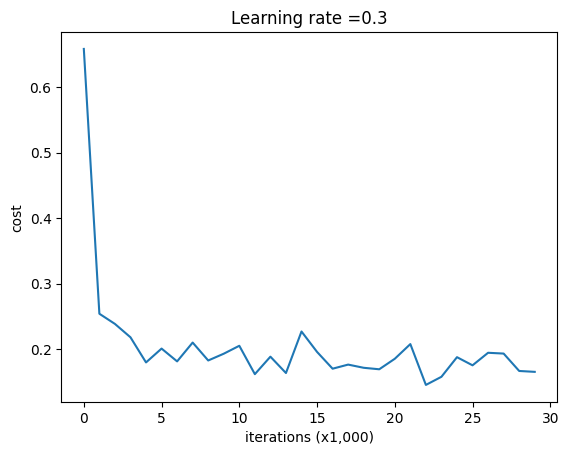

On the train set:
Accuracy: 0.9431279620853081
On the test set:
Accuracy: 0.9349999999999998


In [14]:
parameters = model(train_X, train_Y, 
                    layers_dims=[train_X.shape[0], 20, 3, 1], 
                    learning_rate=0.3, 
                    keep_probs=[0.86, 0.86])

print("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

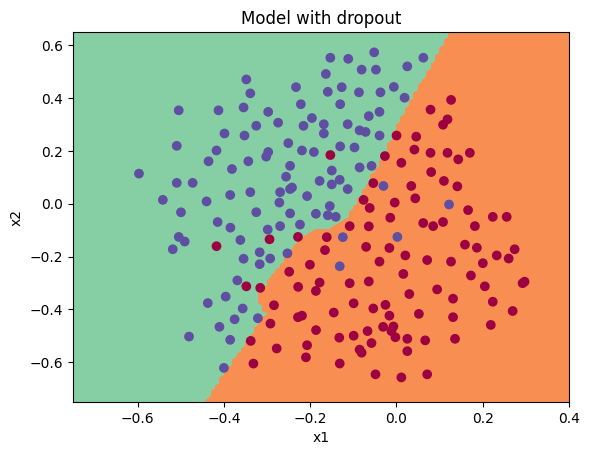

In [15]:
plt.title("Model with dropout")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**What  should remember about dropout:**
- Dropout is a regularization technique.
- You only use dropout during training. Don't use dropout (randomly eliminate nodes) during test time.
- Apply dropout both during forward and backward propagation.
- During training time, divide each dropout layer by keep_prob to keep the same expected value for the activations. For example, if keep_prob is 0.5, then we will on average shut down half the nodes, so the output will be scaled by 0.5 since only the remaining half are contributing to the solution. Dividing by 0.5 is equivalent to multiplying by 2. Hence, the output now has the same expected value. You can check that this works even when keep_prob is other values than 0.5.  